
## <span style="color:red">Análise de Reclamações</span>

PROCESSAMENTO DE LINGUAGEM NATURAL  

**Camille Porto de Sousa**</span>

In [ ]:
import os

# Meu token do Kaggle
os.environ["KAGGLE_TOKEN"] = "KGAT_f2139a88ae6e35559b5d812eb153f88b"

In [ ]:
import kagglehub
import json
import glob
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('rslp', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer

from wordcloud import WordCloud

print("✅ Imports realizados com sucesso!")

✅ Imports realizados com sucesso!


DOWNLOAD DO DATASET

In [ ]:
print("⬇️  Baixando dataset do Kaggle...")
path = kagglehub.dataset_download("beatrizmsarmento/relatos-de-consumidores-do-site-consumidor-gov-br")
print(f"📁 Dataset salvo em: {path}")

⬇️  Baixando dataset do Kaggle...
Using Colab cache for faster access to the 'relatos-de-consumidores-do-site-consumidor-gov-br' dataset.
📁 Dataset salvo em: /kaggle/input/relatos-de-consumidores-do-site-consumidor-gov-br


CARREGAMENTO DO ARQUIVO JSON

In [ ]:
json_files = glob.glob(os.path.join(path, "**", "*.json"), recursive=True)
print(f"📄 Arquivos JSON encontrados: {len(json_files)}")
for f in json_files[:10]:
    print(f"   {f}")

# Carrega todos os JSONs em um único DataFrame
dfs = []
for file in json_files:
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
        # Suporte a JSON como lista ou dict com chave de registros
        if isinstance(data, list):
            dfs.append(pd.DataFrame(data))
        elif isinstance(data, dict):
            # Tenta encontrar a chave com a lista de registros
            for key, value in data.items():
                if isinstance(value, list):
                    dfs.append(pd.DataFrame(value))
                    break
    except Exception as e:
        print(f"⚠️  Erro ao carregar {file}: {e}")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\n📊 Total de registros carregados: {len(df_raw):,}")
print(f"📋 Colunas disponíveis: {list(df_raw.columns)}")

📄 Arquivos JSON encontrados: 1
   /kaggle/input/relatos-de-consumidores-do-site-consumidor-gov-br/dados2025.json

📊 Total de registros carregados: 204,031
📋 Colunas disponíveis: ['id', 'empresa', 'data', 'local', 'status', 'relato', 'resposta', 'nota', 'comentario']


EXPLORAÇÃO INICIAL DO DATASET

In [ ]:
print("=== Primeiras linhas do dataset ===")
display(df_raw.head(3))

print("\n=== Tipos de dados ===")
print(df_raw.dtypes)

print("\n=== Valores nulos por coluna ===")
print(df_raw.isnull().sum())

=== Primeiras linhas do dataset ===


,id,empresa,data,local,status,relato,resposta,nota,comentario
0,1,LG Electronics,2024-01-07,Jacuí - MG,Não Resolvido,Com aproximadamente 3 anos de uso deu um probl...,"Bom dia, Gabriel. \n\nCompreendemos o seu rela...",1,"Como relatei, tenho certeza de que se trata de..."
1,2,Hurb - Hotel Urbano,2024-01-07,Imperatriz - MA,Não Resolvido,Solitei desde 2022 o reembolso o qual não obti...,Finalizamos a sua reclamação e você pode encon...,1,Empresa usa apenas mensagens automáticas e não...
2,3,Hurb - Hotel Urbano,2024-01-07,Três Corações - MG,Não Resolvido,No ano de 2021 comprei um pacote de viagem com...,"Olá, viajante! Tudo bem com você?\n\nFinalizam...",1,Mais uma vez não conseguiram resolver o meu pr...



=== Tipos de dados ===
id             int64
empresa       object
data          object
local         object
status        object
relato        object
resposta      object
nota          object
comentario    object
dtype: object

=== Valores nulos por coluna ===
id            0
empresa       0
data          0
local         0
status        0
relato        0
resposta      0
nota          0
comentario    0
dtype: int64


IDENTIFICAÇÃO DAS COLUNAS DE DATA E EMPRESA

In [ ]:
print("Colunas disponíveis para identificar data e empresa:")
for col in df_raw.columns:
    amostra = str(df_raw[col].dropna().iloc[0]) if df_raw[col].dropna().shape[0] > 0 else "vazio"
    print(f"  '{col}' — amostra: {amostra[:80]}{'...' if len(amostra) > 80 else ''}")

COL_DATA        = "data"
COL_EMPRESA     = "empresa"
COL_RELATO  = "relato"
COL_NOTA        = "nota"
COL_STATUS      = "status"

Colunas disponíveis para identificar data e empresa:
  'id' — amostra: 1
  'empresa' — amostra: LG Electronics
  'data' — amostra: 2024-01-07
  'local' — amostra: Jacuí - MG
  'status' — amostra: Não Resolvido
  'relato' — amostra: Com aproximadamente 3 anos de uso deu um problema na tela da minha TV LED 50 SMA...
  'resposta' — amostra: Bom dia, Gabriel. 

Compreendemos o seu relato, e neste caso gostaríamos de escl...
  'nota' — amostra: 1
  'comentario' — amostra: Como relatei, tenho certeza de que se trata de um vício oculto, tendo em vista a...


FILTRAGEM POR ANO 2024

In [ ]:
df_raw[COL_DATA] = pd.to_datetime(df_raw[COL_DATA], errors="coerce")
df_2024 = df_raw[df_raw[COL_DATA].dt.year == 2024].copy()
df_2024.reset_index(drop=True, inplace=True)

print(f"📅 Registros de 2024: {len(df_2024):,}")
print(f"   Empresas em 2024: {df_2024[COL_EMPRESA].nunique():,}")

📅 Registros de 2024: 81,206
   Empresas em 2024: 925


TOP EMPRESAS COM MAIS RECLAMAÇÕES EM 2024

/tmp/ipykernel_10013/1716623466.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_empresas.values, y=top_empresas.index, palette="Reds_r")


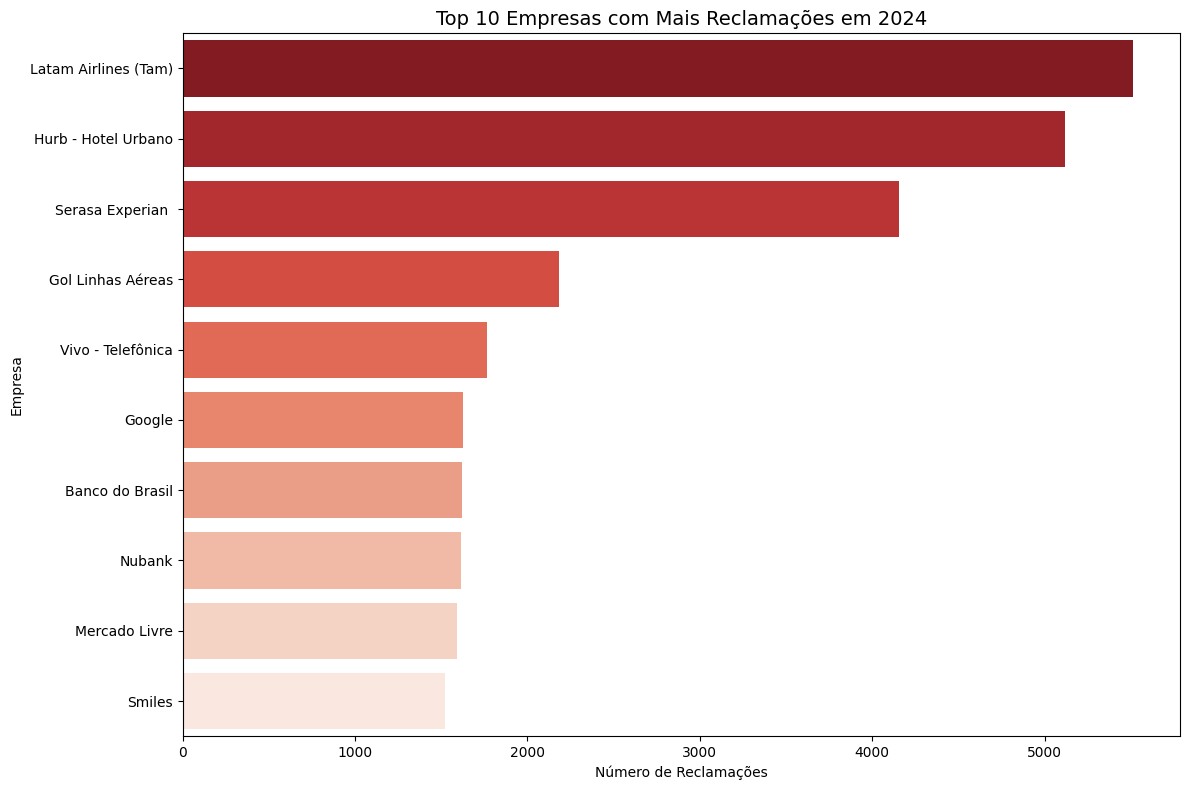


Top 10 empresas:
empresa
Latam Airlines (Tam)    5510
Hurb - Hotel Urbano     5118
Serasa Experian         4155
Gol Linhas Aéreas       2186
Vivo - Telefônica       1764
Google                  1626
Banco do Brasil         1620
Nubank                  1618
Mercado Livre           1591
Smiles                  1521


In [ ]:
top_empresas = df_2024[COL_EMPRESA].value_counts().head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_empresas.values, y=top_empresas.index, palette="Reds_r")
plt.title("Top 10 Empresas com Mais Reclamações em 2024", fontsize=14)
plt.xlabel("Número de Reclamações")
plt.ylabel("Empresa")
plt.tight_layout()
plt.show()

print("\nTop 10 empresas:")
print(top_empresas.head(10).to_string())


SELEÇÃO DA EMPRESA

In [ ]:
EMPRESA_ALVO = "Latam Airlines" #Pode trocar por qualquer outra empresa listada no output da célula anterior :)
df_empresa = df_2024[df_2024[COL_EMPRESA].str.contains(EMPRESA_ALVO, case=False, na=False)].copy()
df_empresa.reset_index(drop=True, inplace=True)

print(f"🏢 Empresa selecionada: {EMPRESA_ALVO}")
print(f"📝 Total de reclamações em 2024: {len(df_empresa):,}")

if len(df_empresa) < 500:
    print("⚠️  Menos de 500 reclamações em 2024. Adicionando anos anteriores...")
    df_empresa_extra = df_raw[df_raw[COL_EMPRESA].str.contains(EMPRESA_ALVO, case=False, na=False)].copy()
    df_empresa = df_empresa_extra.reset_index(drop=True)
    print(f"📝 Total com todos os anos: {len(df_empresa):,}")

🏢 Empresa selecionada: Latam Airlines
📝 Total de reclamações em 2024: 5,510


VISÃO GERAL DA EMPRESA

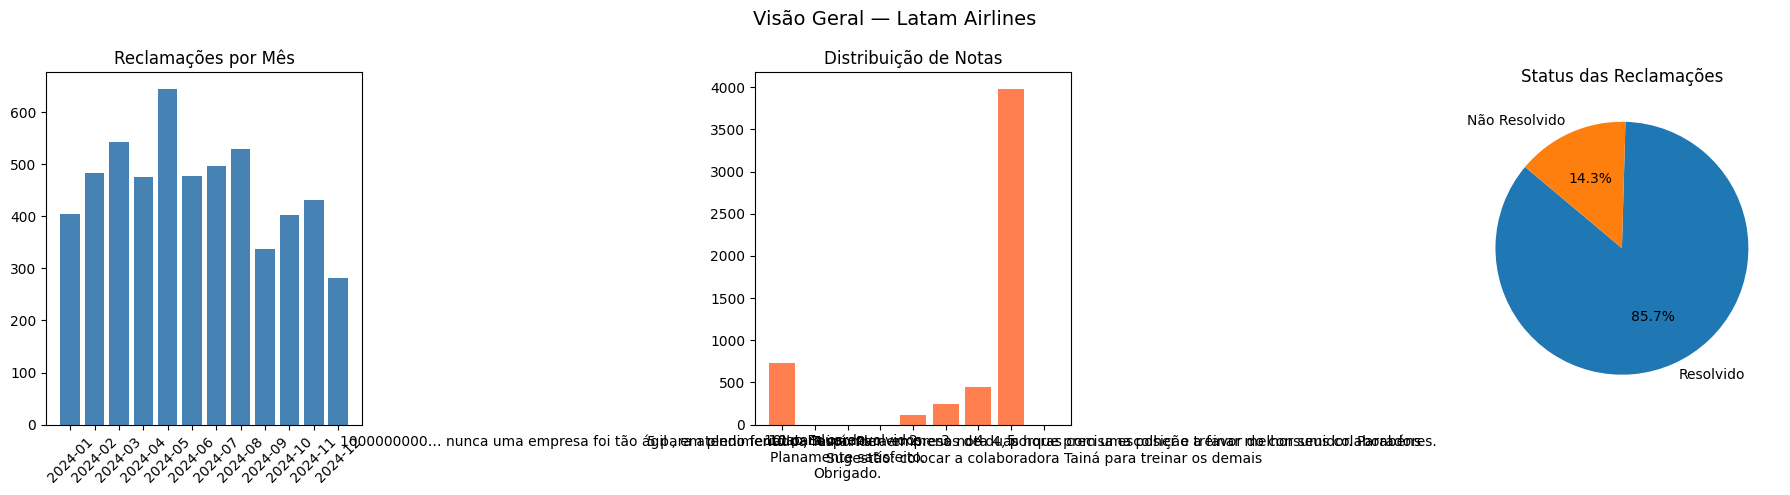

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Visão Geral — {EMPRESA_ALVO}", fontsize=14)

# Reclamações por mês
df_empresa["Mes"] = df_empresa[COL_DATA].dt.to_period("M").astype(str)
contagem_mes = df_empresa["Mes"].value_counts().sort_index()
axes[0].bar(contagem_mes.index, contagem_mes.values, color="steelblue")
axes[0].set_title("Reclamações por Mês")
axes[0].tick_params(axis="x", rotation=45)

# Distribuição de notas (se existir)
if COL_NOTA in df_empresa.columns:
    notas = df_empresa[COL_NOTA].dropna().value_counts().sort_index()
    axes[1].bar(notas.index.astype(str), notas.values, color="coral")
    axes[1].set_title("Distribuição de Notas")
else:
    axes[1].text(0.5, 0.5, "Coluna de nota\nnão encontrada", ha="center", va="center")
    axes[1].set_title("Notas")

# Status das reclamações (se existir)
if COL_STATUS in df_empresa.columns:
    status = df_empresa[COL_STATUS].value_counts()
    axes[2].pie(status.values, labels=status.index, autopct="%1.1f%%", startangle=140)
    axes[2].set_title("Status das Reclamações")
else:
    axes[2].text(0.5, 0.5, "Coluna de status\nnão encontrada", ha="center", va="center")
    axes[2].set_title("Status")

plt.tight_layout()
plt.show()

PRÉ-PROCESSAMENTO: FUNÇÃO DE LIMPEZA

In [ ]:
STOPWORDS_PT = set(stopwords.words("portuguese"))
STOPWORDS_EXTRAS = {
    "empresa", "produto", "serviço", "cliente", "consumidor",
    "dia", "dias", "mês", "meses", "ano", "anos", "vez", "vezes",
    "ainda", "pois", "então", "assim", "também", "muito", "mais",
    "ser", "ter", "fazer", "não", "sim", "já", "só", "lá", "aqui",
    "nao", "pra", "pro", "ta", "tá", "né", "num", "numa",
}
STOPWORDS_FINAL = STOPWORDS_PT | STOPWORDS_EXTRAS

stemmer = RSLPStemmer()


def limpar_texto(texto: str,
                 remover_stopwords: bool = True,
                 aplicar_stemming: bool = False,
                 min_len: int = 3) -> str:


    if not isinstance(texto, str) or not texto.strip():
        return ""

    # 1. Minúsculas
    texto = texto.lower()

    # 2. Remover acentos
    texto = unicodedata.normalize("NFKD", texto)
    texto = texto.encode("ascii", errors="ignore").decode("ascii")

    # 3. Remover URLs e e-mails
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"\S+@\S+", " ", texto)

    # 4. Remover números isolados
    texto = re.sub(r"\b\d+\b", " ", texto)

    # 5. Remover pontuação / caracteres especiais
    texto = re.sub(r"[^a-z\s]", " ", texto)

    # 6. Tokeniza
    tokens = word_tokenize(texto, language="portuguese")

    # 7. Remover stopwords
    if remover_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS_FINAL]

    # 8. Stemming
    if aplicar_stemming:
        tokens = [stemmer.stem(t) for t in tokens]

    # 9. Remover tokens curtos
    tokens = [t for t in tokens if len(t) >= min_len]

    return " ".join(tokens)


print("✅ Função de limpeza definida!")
print("\nExemplo de limpeza:")
exemplo = "Empresa NUNCA responde! Fui cobrado R$150,00 indevidamente em 15/03/2024. Acesse www.reclame.com."
print(f"  Original : {exemplo}")
print(f"  Limpo    : {limpar_texto(exemplo)}")
print(f"  Com stem : {limpar_texto(exemplo, aplicar_stemming=True)}")

✅ Função de limpeza definida!

Exemplo de limpeza:
  Original : Empresa NUNCA responde! Fui cobrado R$150,00 indevidamente em 15/03/2024. Acesse www.reclame.com.
  Limpo    : nunca responde cobrado indevidamente acesse
  Com stem : nunc respond cobr indevid acess


APLICAÇÃO DO PRÉ-PROCESSAMENTO

In [ ]:
print("🔄 Aplicando pré-processamento...")

df_empresa["texto_original"]   = df_empresa[COL_RELATO].astype(str)
df_empresa["texto_limpo"]      = df_empresa["texto_original"].apply(limpar_texto)
df_empresa["texto_stemmed"]    = df_empresa["texto_original"].apply(
    lambda t: limpar_texto(t, aplicar_stemming=True)
)
df_empresa["texto_sem_stop"]   = df_empresa["texto_original"].apply(
    lambda t: limpar_texto(t, remover_stopwords=False)
)

# Métricas básicas
df_empresa["qtd_tokens_original"] = df_empresa["texto_original"].apply(lambda t: len(t.split()))
df_empresa["qtd_tokens_limpo"]    = df_empresa["texto_limpo"].apply(lambda t: len(t.split()))
df_empresa["reducao_pct"]         = (
    1 - df_empresa["qtd_tokens_limpo"] / df_empresa["qtd_tokens_original"].replace(0, np.nan)
) * 100

print("✅ Pré-processamento concluído!")
print(f"\n📉 Redução média de tokens: {df_empresa['reducao_pct'].mean():.1f}%")
print(f"   Tokens originais (média): {df_empresa['qtd_tokens_original'].mean():.1f}")
print(f"   Tokens limpos (média)   : {df_empresa['qtd_tokens_limpo'].mean():.1f}")

# Exibe comparação de 3 exemplos
print("\n=== Comparação antes/depois ===")
for i in range(min(3, len(df_empresa))):
    print(f"\n[{i+1}] Original : {df_empresa.loc[i, 'texto_original'][:200]}")
    print(f"     Limpo    : {df_empresa.loc[i, 'texto_limpo'][:200]}")

🔄 Aplicando pré-processamento...
✅ Pré-processamento concluído!

📉 Redução média de tokens: 49.0%
   Tokens originais (média): 166.9
   Tokens limpos (média)   : 84.2

=== Comparação antes/depois ===

[1] Original : Estava programado para eu ir em um voo GRU-MOC no dia 20/12/23 no entanto o voo contou com overbooking, no qual solicitei meu preterimento de embarque sendo gerado um numero de travel voucher encaminh
     Limpo    : programado voo gru moc entanto voo contou overbooking solicitei preterimento embarque sendo gerado numero travel voucher encaminhado email acontece agora resgatar valor primeiramente site diz travel v

[2] Original : Na vinda em 26.12.2023 eu e minha esposa viemos separados e em bancos do meio, pedi para trocar, tenho 65 anos e diabetes, nem quiseram ouvir. Hoje, tentei fazer o chek in nas 48 horas anteriores, poi
     Limpo    : vinda esposa viemos separados bancos meio pedi trocar diabetes quiseram ouvir hoje tentei chek horas anteriores voo sera teresina bra

ANÁLISE DO IMPACTO DA LIMPEZA

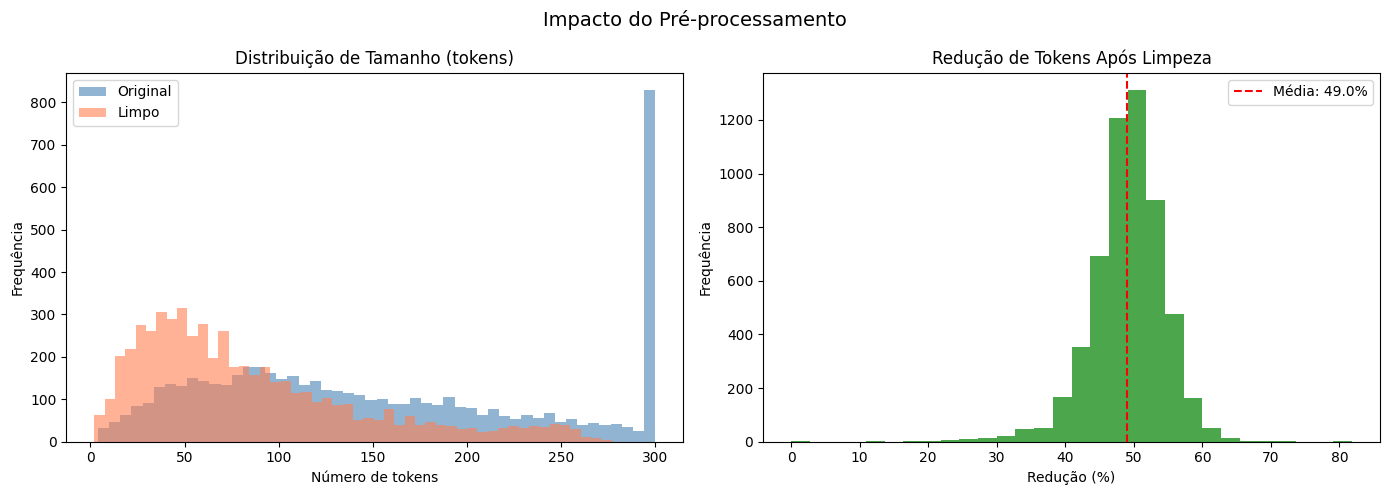

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Impacto do Pré-processamento", fontsize=14)

# Distribuição de tokens
axes[0].hist(df_empresa["qtd_tokens_original"].clip(upper=300), bins=50,
             alpha=0.6, label="Original", color="steelblue")
axes[0].hist(df_empresa["qtd_tokens_limpo"].clip(upper=300), bins=50,
             alpha=0.6, label="Limpo", color="coral")
axes[0].set_title("Distribuição de Tamanho (tokens)")
axes[0].set_xlabel("Número de tokens")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Redução percentual
axes[1].hist(df_empresa["reducao_pct"].dropna().clip(0, 100), bins=30, color="green", alpha=0.7)
axes[1].set_title("Redução de Tokens Após Limpeza")
axes[1].set_xlabel("Redução (%)")
axes[1].set_ylabel("Frequência")
axes[1].axvline(df_empresa["reducao_pct"].mean(), color="red", linestyle="--",
                label=f"Média: {df_empresa['reducao_pct'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

INFORMAÇÕES PERDIDAS DURANTE A NORMALIZAÇÃO

In [ ]:
print("=" * 60)
print("1.2 — INFORMAÇÕES PERDIDAS DURANTE A NORMALIZAÇÃO")
print("=" * 60)

# Exemplo de perdas identificáveis
exemplos_perda = {
    "Números (valores, datas, CPFs)": r"\b\d+\b",
    "URLs (links, provas)": r"http\S+|www\.\S+",
    "E-mails (contatos)": r"\S+@\S+",
    "Pontuação (exclamação/interrogação)": r"[!?]",
    "Maiúsculas (ênfase)": None,  # verificação manual
    "Acentuação (significado sutil)": None,
}

print("\nExemplos de informações que podem ser perdidas:\n")
sample_texts = df_empresa["texto_original"].dropna().head(500)

for info, pattern in exemplos_perda.items():
    if pattern:
        count = sample_texts.str.count(pattern, flags=re.IGNORECASE).sum()
        print(f"  🔹 {info}: {count:,} ocorrências nas primeiras 500 reclamações")
    else:
        print(f"  🔹 {info}: verificar manualmente")

print("""
Conclusões sobre perdas:
  • Números: valores monetários, datas, protocolos e CPFs são removidos.
    Esses dados podem indicar o montante da disputa ou o período do problema.
  • URLs: links para prints ou evidências são perdidos.
  • Acentuação: palavras como 'não' (negação) e 'nao' tornam-se idênticas,
    o que pode ajudar na uniformização mas perde variantes regionais.
  • Stemming: 'cobrança', 'cobrado' e 'cobrar' viram a mesma raiz, facilitando
    agrupamento, mas perde informações morfológicas (tempo verbal, plurais).
  • Stopwords: conectivos como 'não' podem ser removidos se não estiverem na
    lista correta — inverte o sentido da frase!
""")

1.2 — INFORMAÇÕES PERDIDAS DURANTE A NORMALIZAÇÃO

Exemplos de informações que podem ser perdidas:

  🔹 Números (valores, datas, CPFs): 4,501 ocorrências nas primeiras 500 reclamações
  🔹 URLs (links, provas): 6 ocorrências nas primeiras 500 reclamações
  🔹 E-mails (contatos): 8 ocorrências nas primeiras 500 reclamações
  🔹 Pontuação (exclamação/interrogação): 248 ocorrências nas primeiras 500 reclamações
  🔹 Maiúsculas (ênfase): verificar manualmente
  🔹 Acentuação (significado sutil): verificar manualmente

Conclusões sobre perdas:
  • Números: valores monetários, datas, protocolos e CPFs são removidos.
    Esses dados podem indicar o montante da disputa ou o período do problema.
  • URLs: links para prints ou evidências são perdidos.
  • Acentuação: palavras como 'não' (negação) e 'nao' tornam-se idênticas,
    o que pode ajudar na uniformização mas perde variantes regionais.
  • Stemming: 'cobrança', 'cobrado' e 'cobrar' viram a mesma raiz, facilitando
    agrupamento, mas perde in

SALVANDO O DATAFRAME PRÉ-PROCESSADO

In [ ]:
output_file = f"reclamacoes_{EMPRESA_ALVO.replace(' ', '_').replace('/', '')}_2024_preprocessado.csv"
df_empresa.to_csv(output_file, index=False, encoding="utf-8-sig")
print(f"✅ Dataset pré-processado salvo em: {output_file}")

print("\n📊 Resumo final:")
print(f"   Empresa          : {EMPRESA_ALVO}")
print(f"   Reclamações      : {len(df_empresa):,}")
print(f"   Período          : {df_empresa[COL_DATA].min().date()} a {df_empresa[COL_DATA].max().date()}")
print(f"   Colunas geradas  : texto_original, texto_limpo, texto_stemmed, texto_sem_stop")
print(f"   Redução média    : {df_empresa['reducao_pct'].mean():.1f}% dos tokens após limpeza")

✅ Dataset pré-processado salvo em: reclamacoes_Latam_Airlines_2024_preprocessado.csv

📊 Resumo final:
   Empresa          : Latam Airlines
   Reclamações      : 5,510
   Período          : 2024-01-01 a 2024-12-31
   Colunas geradas  : texto_original, texto_limpo, texto_stemmed, texto_sem_stop
   Redução média    : 49.0% dos tokens após limpeza


In [ ]:

print(df_empresa["texto_limpo"].count())


5510


## **2. REPRESENTAÇÃO TEXTUAL**
(Bert - embeddings contextuais)

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

In [ ]:
modelo_bert = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(modelo_bert)
modelo = AutoModel.from_pretrained(modelo_bert)

# corpus pré-processado
corpus = df_empresa["texto_limpo"].dropna().tolist()[:600]

embeddings = []

for texto in corpus:

    inputs = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = modelo(**inputs)

    vetor = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

    embeddings.append(vetor)

embeddings = np.array(embeddings)

print("Shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Shape: (600, 768)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similaridade_bert = cosine_similarity(embeddings)

print(similaridade_bert.shape)

(600, 600)


In [ ]:
indice = 0

scores = list(enumerate(similaridade_bert[indice]))
scores = sorted(scores, key=lambda x: x[1], reverse=True)

print("RECLAMAÇÃO ORIGINAL:")
print(corpus[indice])

print("\nTOP 5 MAIS SEMELHANTES:\n")

for idx, score in scores[1:6]:
    print(f"Similaridade: {score:.4f}")
    print(corpus[idx])
    print("-"*80)

RECLAMAÇÃO ORIGINAL:
programado voo gru moc entanto voo contou overbooking solicitei preterimento embarque sendo gerado numero travel voucher encaminhado email acontece agora resgatar valor primeiramente site diz travel vouhcer vinculado digitando numero travel voucher documento diz numero errado documento sendo correto desejo direito travel voucher imediato

TOP 5 MAIS SEMELHANTES:

Similaridade: 0.8496
voo fiz atraves curitiba santiago chile mala danificada chegando aeroporto santiago mostrei mala atendente forneceu documento ressarcir valor fiz registro site latam gerado travel voucher numero xxx xxx xxx seguida utilizar numero travel voucher depositar valor latam wallet entanto numero passaporte aparecia correlacionado numero travel voucher consegui realizar deposito latam wallet prazo travel voucher valido ate xxxxx xxxxxx entanto tentei dentro desse periodo todas formas realizar ressarcimento possivel
-------------------------------------------------------------------------------

In [ ]:
import pandas as pd

pd.DataFrame(similaridade_bert[:10, :10])

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.765111,0.758762,0.819373,0.773301,0.617773,0.793711,0.769335,0.778532,0.766793
1,0.765111,1.000000,0.838779,0.839743,0.866942,0.715764,0.805634,0.828969,0.847106,0.817636
2,0.758762,0.838779,1.000000,0.842716,0.846543,0.649361,0.823798,0.826181,0.847941,0.806216
3,0.819373,0.839743,0.842716,1.000000,0.859309,0.662124,0.883687,0.874998,0.912226,0.866265
4,0.773301,0.866942,0.846543,0.859309,1.000000,0.710413,0.815013,0.848460,0.870961,0.851063
5,0.617773,0.715764,0.649361,0.662124,0.710413,1.000000,0.627333,0.707918,0.654790,0.665038
6,0.793711,0.805634,0.823798,0.883687,0.815013,0.627333,1.000000,0.868604,0.914262,0.879902
7,0.769335,0.828969,0.826181,0.874998,0.848460,0.707918,0.868604,1.000000,0.884602,0.895873
8,0.778532,0.847106,0.847941,0.912226,0.870961,0.654790,0.914262,0.884602,1.000000,0.913939
9,0.766793,0.817636,0.806216,0.866265,0.851063,0.665038,0.879902,0.895873,0.913939,1.000000


**(Bag of Words - Representação baseada em frequência)**




In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity


vectorizer = CountVectorizer()

bow_matrix = vectorizer.fit_transform(corpus)

print("Shape BoW:", bow_matrix.shape)

Shape BoW: (600, 7585)


In [ ]:
similaridade_bow = cosine_similarity(bow_matrix)

indice = 0

scores = list(enumerate(similaridade_bow[indice]))
scores = sorted(scores, key=lambda x: x[1], reverse=True)

print("RECLAMAÇÃO CONSULTADA:\n")
print(corpus[indice])

print("\nTOP 5 MAIS SEMELHANTES (Bag of Words)\n")

for idx, score in scores[1:6]:
    print(f"Similaridade: {score:.4f}")
    print(corpus[idx][:400])
    print("-"*80)

RECLAMAÇÃO CONSULTADA:

programado voo gru moc entanto voo contou overbooking solicitei preterimento embarque sendo gerado numero travel voucher encaminhado email acontece agora resgatar valor primeiramente site diz travel vouhcer vinculado digitando numero travel voucher documento diz numero errado documento sendo correto desejo direito travel voucher imediato

TOP 5 MAIS SEMELHANTES (Bag of Words)

Similaridade: 0.5030
voo fiz atraves curitiba santiago chile mala danificada chegando aeroporto santiago mostrei mala atendente forneceu documento ressarcir valor fiz registro site latam gerado travel voucher numero xxx xxx xxx seguida utilizar numero travel voucher depositar valor latam wallet entanto numero passaporte aparecia correlacionado numero travel voucher consegui realizar deposito latam wallet prazo travel 
--------------------------------------------------------------------------------
Similaridade: 0.3060
devido atraso voo bcn gru duas horas atraso possivel embarcar voo gru vi

## **COMPARAÇÃO BERT X Bag of Words**

In [ ]:
similaridade_bert = cosine_similarity(embeddings)

indice = 0

print("="*100)
print("RECLAMAÇÃO ORIGINAL")
print("="*100)
print(corpus[indice])

print("\n\n")
print("="*100)
print("TOP 5 - BAG OF WORDS")
print("="*100)

scores_bow = sorted(
    enumerate(similaridade_bow[indice]),
    key=lambda x: x[1],
    reverse=True
)

for idx, score in scores_bow[1:6]:
    print(f"\nScore: {score:.4f}")
    print(corpus[idx][:300])

print("\n\n")
print("="*100)
print("TOP 5 - BERT")
print("="*100)

scores_bert = sorted(
    enumerate(similaridade_bert[indice]),
    key=lambda x: x[1],
    reverse=True
)

for idx, score in scores_bert[1:6]:
    print(f"\nScore: {score:.4f}")
    print(corpus[idx][:300])

RECLAMAÇÃO ORIGINAL
programado voo gru moc entanto voo contou overbooking solicitei preterimento embarque sendo gerado numero travel voucher encaminhado email acontece agora resgatar valor primeiramente site diz travel vouhcer vinculado digitando numero travel voucher documento diz numero errado documento sendo correto desejo direito travel voucher imediato



TOP 5 - BAG OF WORDS

Score: 0.5030
voo fiz atraves curitiba santiago chile mala danificada chegando aeroporto santiago mostrei mala atendente forneceu documento ressarcir valor fiz registro site latam gerado travel voucher numero xxx xxx xxx seguida utilizar numero travel voucher depositar valor latam wallet entanto numero passaporte

Score: 0.3060
devido atraso voo bcn gru duas horas atraso possivel embarcar voo gru vix sendo realocado voo gru vix posterior solicito enviado email carta documento comprove realocacao voo fins comprobatorios documento anexo entregue porem valor comprobatorio aberto chamado junto responde atende ch

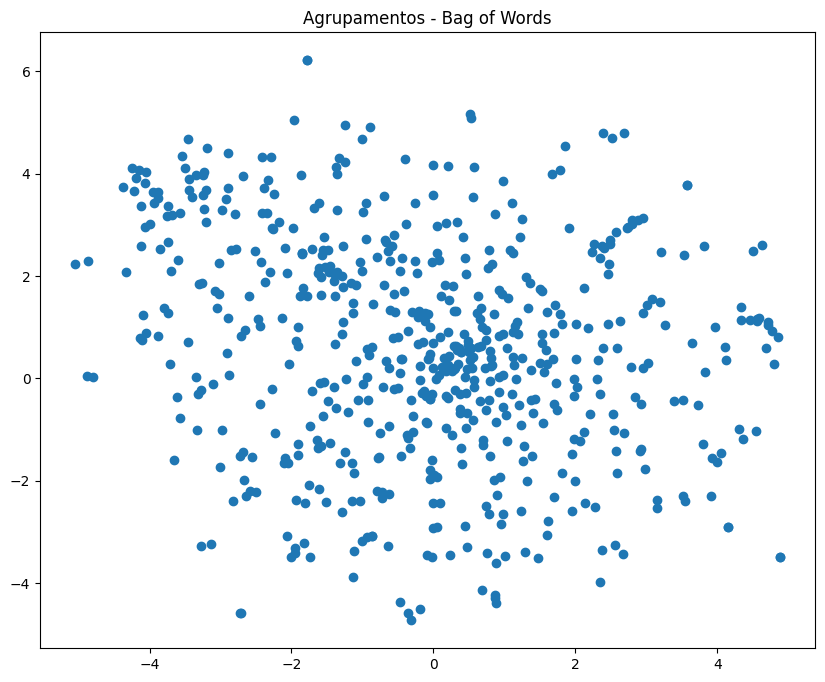

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
#foi utilizada a técnica t-SNE, responsável por reduzir os vetores de alta dimensionalidade para duas dimensões, onde cada ponto representa uma reclamação do corpus.
coords_bow = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
).fit_transform(bow_matrix.toarray())

plt.figure(figsize=(10,8))
plt.scatter(coords_bow[:,0], coords_bow[:,1])

plt.title("Agrupamentos - Bag of Words")
plt.show()

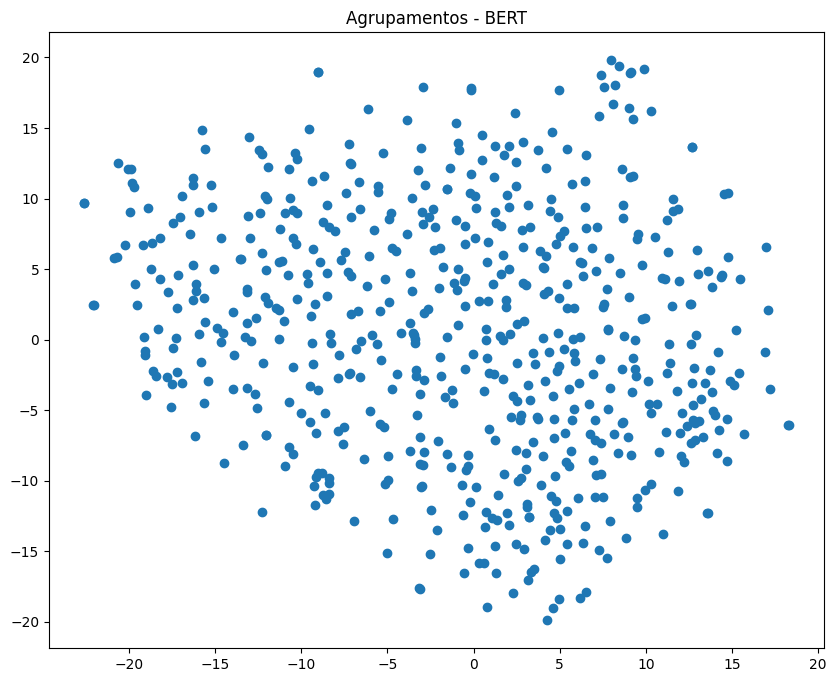

In [ ]:
coords_bert = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
).fit_transform(embeddings)

plt.figure(figsize=(10,8))
plt.scatter(coords_bert[:,0], coords_bert[:,1])

plt.title("Agrupamentos - BERT")
plt.show()


# 3. **IDENTIFICAÇÃO DE GRAUS DE SEVERIDADE**




In [ ]:
from sklearn.cluster import KMeans
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

In [ ]:
#cria cópia apenas dos registros utilizados no BERT
df_cluster = df_empresa.iloc[:len(embeddings)].copy()

#agrupamento em 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(embeddings)

df_cluster["cluster"] = clusters

print("="*80)
print("QUANTIDADE DE RECLAMAÇÕES POR CLUSTER")
print("="*80)
print(df_cluster["cluster"].value_counts())

QUANTIDADE DE RECLAMAÇÕES POR CLUSTER
cluster
0    285
1    211
2    104
Name: count, dtype: int64


In [ ]:
#visualização dos clusters (10 reclamações de cada)
for c in sorted(df_cluster["cluster"].unique()):

    print("\n")
    print("="*100)
    print(f"CLUSTER {c}")
    print("="*100)

    exemplos = (
        df_cluster[df_cluster["cluster"] == c]
        ["texto_original"]
        .head(10)
    )

    for i, texto in enumerate(exemplos, start=1):
        print(f"\nExemplo {i}:")
        print(texto[:1000])
        print("-"*100)



CLUSTER 0

Exemplo 1:
Estava programado para eu ir em um voo GRU-MOC no dia 20/12/23 no entanto o voo contou com overbooking, no qual solicitei meu preterimento de embarque sendo gerado um numero de travel voucher encaminhado ao meu email. Acontece, que agora, para resgatar o valor, primeiramente o site ja diz que não ha travel vouhcer vinculado e mesmo digitando o numero do travel voucher e o documento, o mesmo diz que e/ou numero esta errado ou do documento, sendo que esta correto.
Desejo ter direito ao meu travel voucher de imediato.
----------------------------------------------------------------------------------------------------

Exemplo 2:
Na vinda em 26.12.2023 eu e minha esposa viemos separados e em bancos do meio, pedi para trocar, tenho 65 anos e diabetes, nem quiseram ouvir. Hoje, tentei fazer o chek in nas 48 horas anteriores, pois o voo será em 09.01.24 de Teresina/ Brasília/ São Paulo, e novamente a empresa já fez o chek in e nos colocou nos dois voos em fileiras sepa

**O que parece em cada cluster...**

Cluster 0

*   overbooking
*  cobrança indevida de bagagem
*  bagagem avariada
*  dificuldade de atendimento
*  bloqueio de milhas
*  problemas de check-in

Moderada -  Prejuízo financeiro e transtorno significativo

Cluster 1

*  passageiro com necessidades especiais prejudicado
*  perda de viagem internacional
*  reembolso de valores elevados
*  extravio de bagagem
*  cancelamento sem assistência
*  grandes prejuízos financeiros

Grave - Relatos mais longos e impactos mais sérios

Cluster 2

*   cancelamento de passagem
*   pedido de reembolso
*   alteração de voo
*   solicitação de documento
*   problemas administrativos

Leve - Reclamações mais curtas e relativamente simples






In [ ]:
#determinação do grau de severidade de cada cluster (justificativa das escolhas nas células acima...)
mapa_severidade = {
    2: "Leve",
    0: "Moderada",
    1: "Grave"
}

df_cluster["severidade"] = (
    df_cluster["cluster"]
    .map(mapa_severidade)
)

In [ ]:
#quantidade de reclamações por severidade
print("="*50)
print("DISTRIBUIÇÃO DAS SEVERIDADES")
print("="*50)

print(df_cluster["severidade"].value_counts())


DISTRIBUIÇÃO DAS SEVERIDADES
severidade
Moderada    285
Grave       211
Leve        104
Name: count, dtype: int64


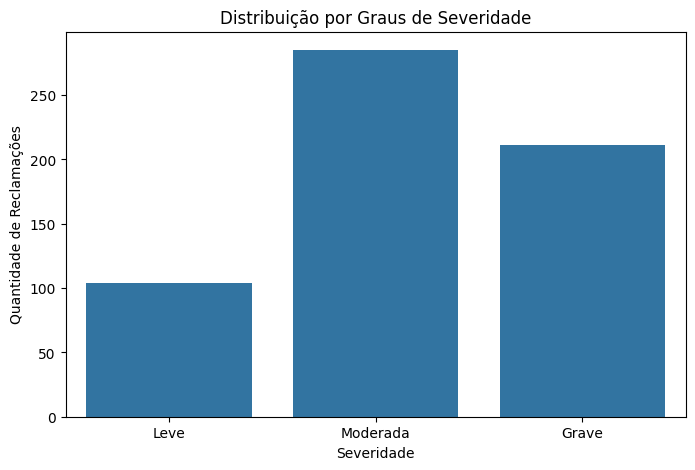

In [ ]:
#gráfico da quantidade de reclamações por severidade
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_cluster,
    x="severidade",
    order=["Leve", "Moderada", "Grave"]
)

plt.title("Distribuição por Graus de Severidade")
plt.xlabel("Severidade")
plt.ylabel("Quantidade de Reclamações")

plt.show()


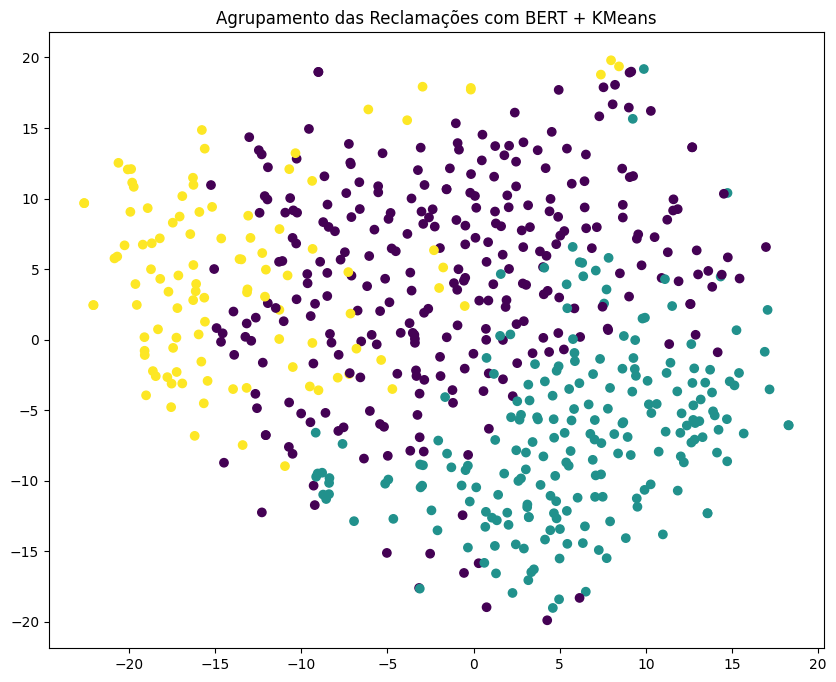

In [ ]:
#gráfico do agrupamento das reclamações classificadas
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    coords_bert[:,0],
    coords_bert[:,1],
    c=clusters
)

plt.title("Agrupamento das Reclamações com BERT + KMeans")

plt.show()


**Critérios para justificar os graus**



As reclamações classificadas como leves correspondem a inconvenientes operacionais e demandas administrativas, como solicitações de informações, alterações de serviços, cancelamentos com possibilidade de resolução e pedidos de reembolso, que normalmente geram insatisfação, mas apresentam impacto limitado.

As reclamações moderadas envolvem situações que causam prejuízos temporários ou transtornos mais relevantes, incluindo cobranças indevidas, problemas de atendimento, falhas operacionais e dificuldades relacionadas à utilização dos serviços contratados.

Já as reclamações graves abrangem ocorrências com consequências mais significativas para o consumidor, como perdas financeiras expressivas, extravio de bens, cancelamentos sem assistência adequada e situações que caracterizam descumprimento dos direitos do consumidor.

**Técnicas utilizadas para chegar na classificação**

O K-Means foi utilizado para realizar o agrupamento das reclamações com base nos embeddings gerados pelo modelo BERT. Trata-se de uma técnica de aprendizado não supervisionado, ou seja, não necessita de categorias previamente definidas para identificar padrões nos dados. Inicialmente, o algoritmo define um número fixo de grupos (k) e cria centróides iniciais. Em seguida, cada reclamação é associada ao centróide mais próximo de acordo com a distância entre seus vetores numéricos. Após essa etapa, os centróides são recalculados considerando a média dos elementos de cada grupo, e o processo é repetido até que os agrupamentos se estabilizem. Neste trabalho, foi adotado k = 3 para possibilitar a identificação de três níveis de severidade das reclamações. A partir dos agrupamentos obtidos, realizou-se uma análise dos relatos presentes em cada cluster, permitindo interpretar os grupos como reclamações de severidade leve, moderada e grave de acordo com o impacto relatado pelos consumidores.

https://www.ibm.com/br-pt/think/topics/k-means-clustering


A análise das reclamações mostrou que o cluster 2 continha predominantemente solicitações administrativas e problemas de menor impacto, sendo classificado como leve. O cluster 0 concentrou problemas operacionais e financeiros moderados, já o cluster 1 reuniu relatos envolvendo elevados prejuízos financeiros, extravio de bagagem e cancelamentos sem suporte adequado, sendo interpretado como o grupo de maior severidade.


Pelo gráfico gerado, observa-se que a maioria dos pontos de mesma cor, que representam reclamações pertencentes ao mesmo cluster, ficou relativamente próxima, indicando que o modelo foi capaz de agrupar reclamações semanticamente semelhantes de forma satisfatória.

Entretanto, alguns pontos aparecem mais dispersos ou próximos de outros grupos, sugerindo que certas reclamações compartilham características de diferentes clusters. Uma possível alternativa para melhorar a separação dos agrupamentos seria aumentar o número de clusters, permitindo uma representação mais detalhada dos diferentes tipos de reclamações presentes no conjunto de dados.
(Poderia entrar como uma "limitação"...)

#   **4. DISCUSSÃO CRÍTICA**

**Qual representação funcionou melhor?**

A representação utilizando BERT (embeddings contextuais) funcionou significativamente melhor do que o modelo Bag of Words (BoW)
. Enquanto o BoW apresentou scores de similaridade que caíam rapidamente (de 0.50 para 0.20 entre os principais resultados), o BERT manteve scores altos e consistentes, acima de 0.83 para os cinco resultados mais semelhantes
. Além disso, a visualização por t-SNE e o agrupamento por K-Means demonstraram que o BERT consegue captar relações semânticas e agrupar reclamações por temas de forma mais coesa.


**O pré-processamento alterou os resultados?**

Sim, o pré-processamento teve um impacto profundo na estrutura dos dados, resultando em uma redução média de 49% dos tokens originais
. A limpeza removeu ruídos como URLs, e-mails e números isolados, simplificando o modelo, mas também gerou perdas de informações que poderiam ser relevantes para a análise de severidade, como valores monetários e números de protocolo
. A normalização (letras minúsculas e remoção de acentos) também eliminou nuances de ênfase e indignação dos consumidores



**Modelos contextuais trouxeram vantagens?**

Sim, os modelos contextuais (BERT) trouxeram a vantagem de identificar similaridade semântica mesmo quando as palavras exatas não são idênticas
. O BoW depende da frequência de palavras exatas, o que explica seus scores de similaridade mais baixos em relatos que tratam do mesmo tema com vocabulário variado
. O BERT, por outro lado, conseguiu agrupar relatos de problemas complexos (como overbooking e danos em bagagens) com uma precisão semântica muito superior
.

**As reclamações mais graves possuem características linguísticas específicas?**

As reclamações classificadas como "Graves" (Cluster 1) apresentam características distintas:
 São relatos mais longos e detalhados
.
 Focam em impactos sérios como perda de viagem internacional, reembolso de valores elevados, extravio de bagagem e grandes prejuízos financeiros
.
 Embora o estudo aponte que elementos como números (valores e protocolos) e pontuação de indignação (exclamações) são frequentemente removidos no pré-processamento, eles são marcas linguísticas típicas de relatos de maior gravidade
.


**Quais limitações foram encontradas?**

As principais limitações estão relacionadas à perda de informação durante a normalização:
Dados Numéricos: A remoção de valores de reembolso e números de CPF/protocolo impede a análise exata da disputa financeira
.
Negação: A remoção de certas stopwords (como "não") ou o processo de stemming pode inverter o sentido original da frase, tratando "não funcionou" e "funcionou" como similares
.
Ênfase e Emoção: A conversão para minúsculas e remoção de caracteres especiais descarta o uso de letras maiúsculas e pontuação excessiva, que são formas essenciais de o consumidor expressar urgência e gravidade
.
Ambiguidade: A remoção de acentos pode causar perda de significados sutis e nuances regionais
.
